# Support Ticket Classification & Prioritization

**Machine Learning Internship - Task 2**
*Future Interns | Track Code: ML | Repository: FUTURE_ML_02*

---

### Author
**Rohit Kumar Malik** - AI & Cybersecurity Graduate

- LinkedIn: https://www.linkedin.com/in/rohitmalik7
- GitHub: https://github.com/RohitMalik7
- Email: rohitmalik180904@gmail.com

---

### Project Objective
Real support teams receive hundreds or thousands of tickets every day, and a
big share of their time is lost just sorting them - figuring out *what kind*
of ticket it is, and *how urgent* it is. This project builds an ML-powered
decision-support system that does both jobs automatically:

1. **Category Classification** - a machine learning model that reads a
   ticket's text and predicts which category it belongs to (e.g., Hardware,
   Access, HR Support).
2. **Priority Tagging** - a transparent rule-based system that scans the
   ticket text for urgency signals and assigns a priority level (High,
   Medium, or Low).

The output is a system a support manager or SaaS founder could use to
**route tickets faster, reduce backlog, and respond to urgent issues first**.

### Dataset Overview
| Property | Detail |
|----------|--------|
| Source | IT Service Ticket Classification Dataset (Kaggle, adisongoh) |
| Records | 47,837 real IT helpdesk tickets |
| Columns | 2 - `Document` (ticket text) and `Topic_group` (category) |
| Categories | 8 (Hardware, HR Support, Access, Miscellaneous, Storage, Purchase, Internal Project, Administrative rights) |
| Domain | Internal IT helpdesk |
| Data Quality | No missing values |

The dataset has real ticket text and clean category labels, but no priority
column - so priority is derived from the ticket text itself using rule-based
urgency scoring (a realistic approach used in many real helpdesks).

### Approach
1. Clean and preprocess the ticket text (lowercase, remove punctuation/numbers,
   remove stopwords, lemmatize)
2. Explore category distribution, ticket length, and most common words
3. Convert text into numerical features using TF-IDF
4. Train and compare classification models (Logistic Regression, LinearSVC,
   Naive Bayes)
5. Evaluate using accuracy, precision, recall, F1, and a confusion matrix
6. Build a rule-based priority system using urgency keywords
7. Demo the full pipeline on sample tickets, then summarize business insights

## Phase 1 - Setup & Project Structure

We start by importing the core libraries, downloading the NLTK resources we
need for text cleaning, and programmatically creating a clean, reproducible
folder structure. Building the folders in code (rather than by hand) is a
professional convention - anyone can re-run this notebook and get the exact
same project layout.

In [1]:
# ---------- Core Libraries ----------
import os
import re
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- NLP Libraries ----------
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download the NLTK resources we'll use for cleaning the ticket text
# (only downloads once; quiet=True keeps the output clean)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("omw-1.4", quiet=True)

# ---------- Display & plot settings for a clean, professional look ----------
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13

# ---------- Project Folder Structure ----------
PROJECT = "FUTURE_ML_02"

folders = [
    f"{PROJECT}/data/raw",         # original dataset (never edited)
    f"{PROJECT}/data/processed",   # cleaned / feature-ready data
    f"{PROJECT}/notebooks",        # this notebook
    f"{PROJECT}/reports/figures",  # exported charts for README & LinkedIn
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project structure created successfully:\n")
for folder in folders:
    print("  -", folder)

Project structure created successfully:

  - FUTURE_ML_02/data/raw
  - FUTURE_ML_02/data/processed
  - FUTURE_ML_02/notebooks
  - FUTURE_ML_02/reports/figures


## Phase 2 - Loading the Dataset

The dataset can be loaded in two ways. Choose whichever suits your setup:

- **Option 1 - Google Drive:** if you've saved the CSV to your Drive
  (good for re-running the notebook later without re-uploading).
- **Option 2 - Local Upload (active):** upload the CSV directly from your
  computer for this session.

In [2]:
# ===================== OPTION 1: Load from Google Drive =====================
# Uncomment the 3 lines below if your CSV is saved in Google Drive.
#
# from google.colab import drive
# drive.mount('/content/drive')
# csv_path = '/content/drive/MyDrive/all_tickets_processed_improved_v3.csv'   # adjust path if needed


# ===================== OPTION 2: Upload from Local Machine (ACTIVE) ==========
from google.colab import files
print("Please select the ticket dataset CSV from your computer:")
uploaded = files.upload()

# Automatically use whatever filename was uploaded (handles spaces, etc.)
csv_path = list(uploaded.keys())[0]
print("File received:", csv_path)


# ---------- Load the dataset ----------
df = pd.read_csv(csv_path)

# ---------- Keep a clean copy of the raw file inside the project structure ----------
shutil.copy(csv_path, f"{PROJECT}/data/raw/all_tickets_processed_improved_v3.csv")

# ---------- Quick confirmation that the data loaded correctly ----------
print(f"\nDataset loaded successfully - shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

df.head()

Please select the ticket dataset CSV from your computer:


Saving all_tickets_processed_improved_v3.csv to all_tickets_processed_improved_v3.csv
File received: all_tickets_processed_improved_v3.csv

Dataset loaded successfully - shape: 47,837 rows x 2 columns

Missing values: 0
Duplicate rows: 0


,Document,Topic_group
0,connection with icon icon dear please setup icon per icon engineers please let other details needed thanks lead,Hardware
1,work experience user work experience user hi work experience student coming next his name much appreciate him durati...,Access
2,requesting for meeting requesting meeting hi please help follow equipments cable pc cord plug,Hardware
3,reset passwords for external accounts re expire days hi ask help update passwords colleagues thank pm expire days im...,Access
4,mail verification warning hi has got attached please addresses best regards monitoring analyst verification warning,Miscellaneous


## Phase 3 - Data Inspection

Before touching the text, we run a professional sanity check to understand
what we're working with - the structure, the category distribution, the typical
length of a ticket, and a few sample texts. This step tells us exactly what
cleaning the data needs and helps us spot any class-imbalance issues to handle
later.

In [3]:
# ---------- 1. Structure & Data Types ----------
print("=" * 60)
print("DATASET STRUCTURE")
print("=" * 60)
df.info()

# ---------- 2. Category Distribution ----------
print("\n" + "=" * 60)
print("CATEGORY DISTRIBUTION")
print("=" * 60)
cat_counts = df["Topic_group"].value_counts()
print(cat_counts)
print(f"\nNumber of unique categories: {df['Topic_group'].nunique()}")

# ---------- 3. Ticket Length (in words) ----------
print("\n" + "=" * 60)
print("TICKET LENGTH (in words)")
print("=" * 60)
word_lengths = df["Document"].astype(str).str.split().apply(len)
print(word_lengths.describe().round(1))

# ---------- 4. Sample Tickets from Different Categories ----------
print("\n" + "=" * 60)
print("SAMPLE TICKETS (one per category)")
print("=" * 60)
for category in df["Topic_group"].unique():
    sample = df[df["Topic_group"] == category]["Document"].iloc[0]
    print(f"\n[{category}]")
    print(f"   {str(sample)[:200]}")

DATASET STRUCTURE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47837 entries, 0 to 47836
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Document     47837 non-null  object
 1   Topic_group  47837 non-null  object
dtypes: object(2)
memory usage: 747.6+ KB

CATEGORY DISTRIBUTION
Topic_group
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760
Name: count, dtype: int64

Number of unique categories: 8

TICKET LENGTH (in words)
count    47837.0
mean        43.6
std         56.7
min          2.0
25%         17.0
50%         26.0
75%         46.0
max        981.0
Name: Document, dtype: float64

SAMPLE TICKETS (one per category)

[Hardware]
   connection with icon icon dear please setup icon per icon engineers please let other

## Phase 4 - Text Cleaning & Preprocessing

ML models can't read raw text - they need clean, normalized words. We build a
pipeline that performs five standard NLP cleaning steps on every ticket:

1. **Lowercase** the text so "Server" and "server" are treated as the same word.
2. **Remove digits and special characters** (URLs, punctuation, numbers).
3. **Tokenize** the text into individual words.
4. **Remove stopwords** like "the", "is", "and" - they add no meaning.
5. **Lemmatize** each word to its base form ("running" → "run", "issues" → "issue").

The dataset has been partially pre-cleaned by its author, but applying this
pipeline ensures consistency and gives us a proper, professional cleaning step
to show in the project.

In [4]:
# ---------- Set up the cleaning tools once (faster than re-creating per row) ----------
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

# ---------- Reusable text-cleaning function ----------
def clean_text(text):
    """Run a full NLP cleaning pipeline on a single ticket."""
    # Safety check for non-string values
    if not isinstance(text, str):
        return ""

    # 1. Lowercase
    text = text.lower()

    # 2. Remove URLs, digits and anything that isn't a letter/space
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)

    # 3. Tokenize
    tokens = word_tokenize(text)

    # 4. Remove stopwords + 5. Lemmatize, in one pass
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words and len(t) > 2]

    return " ".join(tokens)

# ---------- Apply the pipeline to every ticket ----------
print("Cleaning 47,837 tickets... (this takes ~1-2 minutes)")
df["clean_text"] = df["Document"].apply(clean_text)
print("Done.\n")

# ---------- Quick before-vs-after check on the first 3 tickets ----------
print("BEFORE vs AFTER CLEANING:")
print("-" * 60)
for i in range(3):
    print(f"\n[Ticket {i+1} - {df.iloc[i]['Topic_group']}]")
    print("  BEFORE:", str(df.iloc[i]["Document"])[:140])
    print("  AFTER :", str(df.iloc[i]["clean_text"])[:140])

# ---------- Save the cleaned dataset to the processed folder ----------
df[["clean_text", "Topic_group"]].to_csv(
    f"{PROJECT}/data/processed/tickets_cleaned.csv", index=False
)
print(f"\nSaved -> {PROJECT}/data/processed/tickets_cleaned.csv")

Cleaning 47,837 tickets... (this takes ~1-2 minutes)
Done.

BEFORE vs AFTER CLEANING:
------------------------------------------------------------

[Ticket 1 - Hardware]
  BEFORE: connection with icon icon dear please setup icon per icon engineers please let other details needed thanks lead
  AFTER : connection icon icon dear please setup icon per icon engineer please let detail needed thanks lead

[Ticket 2 - Access]
  BEFORE: work experience user work experience user hi work experience student coming next his name much appreciate him duration thank
  AFTER : work experience user work experience user work experience student coming next name much appreciate duration thank

[Ticket 3 - Hardware]
  BEFORE: requesting for meeting requesting meeting hi please help follow equipments cable pc cord plug
  AFTER : requesting meeting requesting meeting please help follow equipment cable cord plug

Saved -> FUTURE_ML_02/data/processed/tickets_cleaned.csv


## Phase 5 - Exploratory Data Analysis (EDA)

With the text cleaned, we now explore the data visually to understand its
shape before modelling. We look at three things:

1. **Category distribution** - how tickets are spread across the 8 categories.
   This tells us about class imbalance, which we'll need to handle in the
   train/test split.
2. **Ticket length distribution** - how long tickets typically are (in words).
3. **Most common words per category** - proof that different categories
   actually use different vocabulary, which is what makes ML classification
   possible.

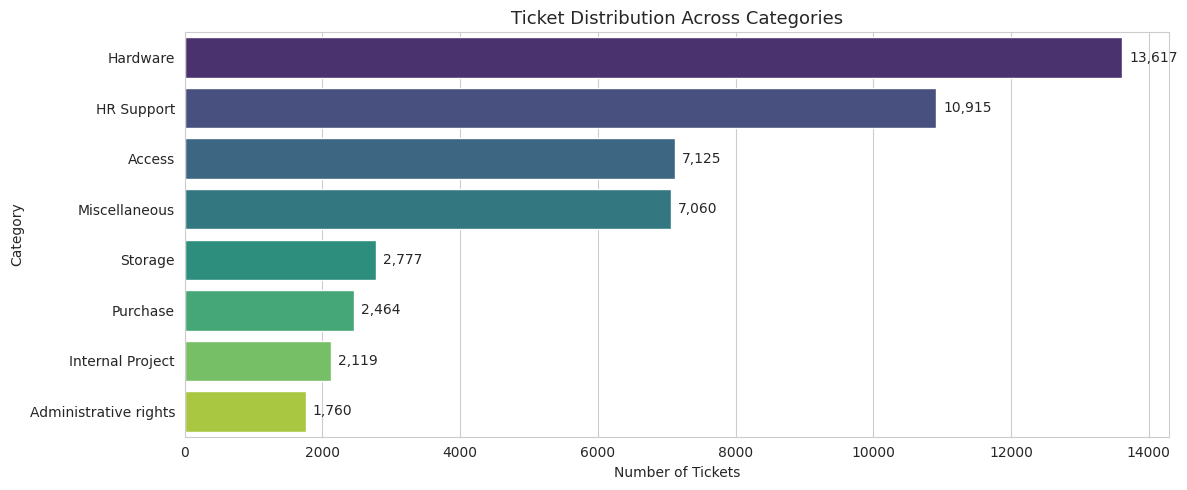

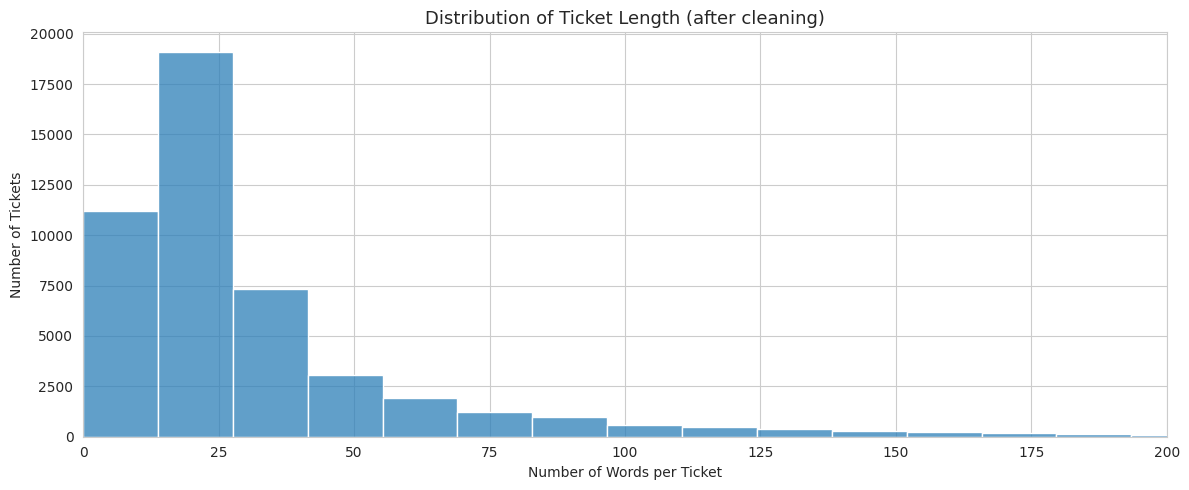

Average ticket length: 35.2 words
Median  ticket length: 22 words


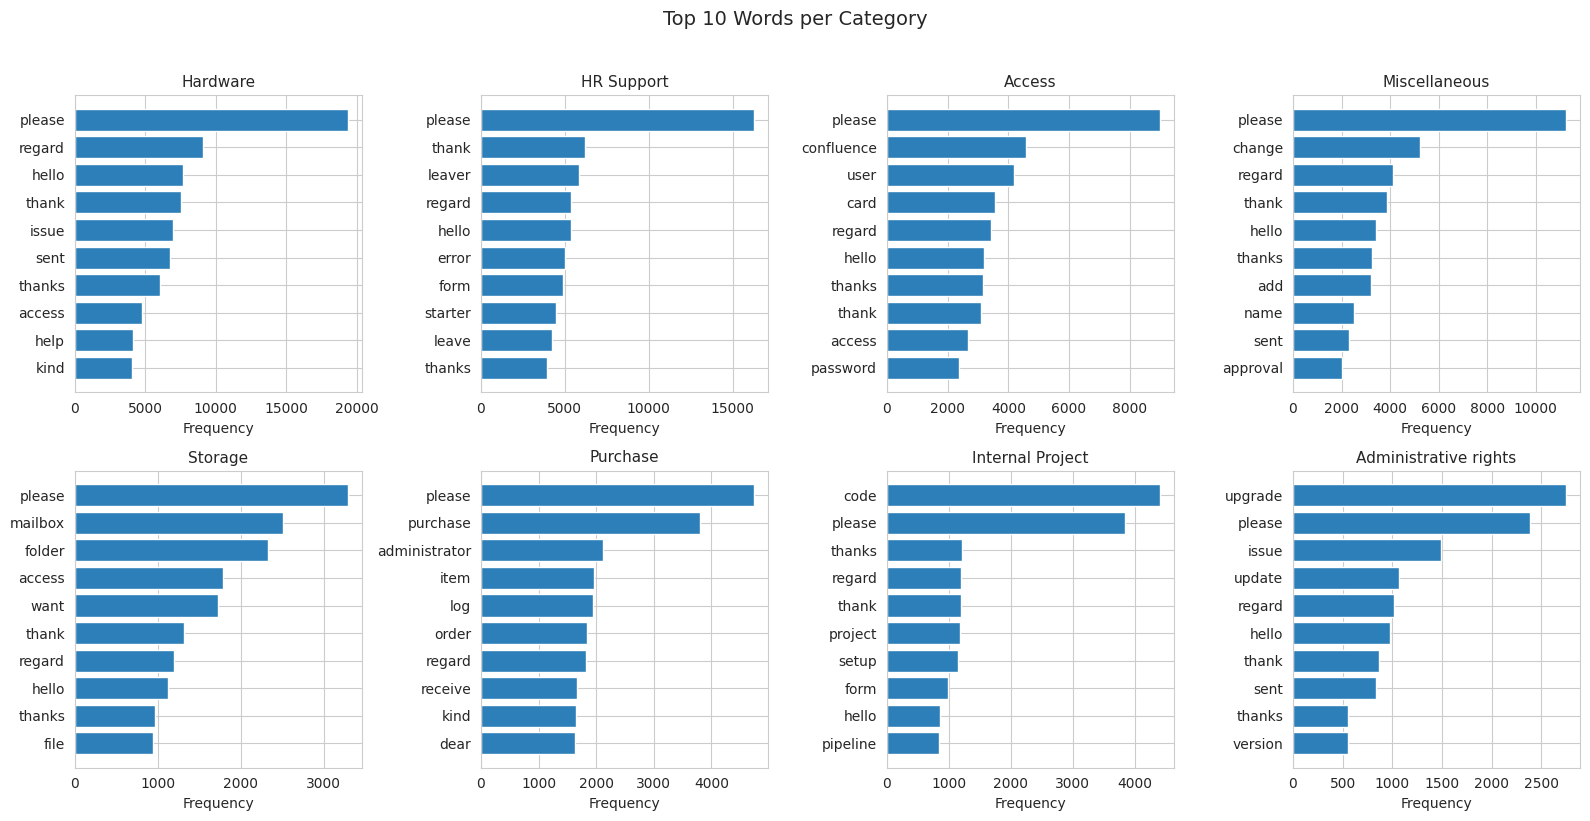

In [5]:
from collections import Counter

# ============================================================
# CHART 1 - Category Distribution
# ============================================================
cat_counts = df["Topic_group"].value_counts()

plt.figure(figsize=(12, 5))
sns.barplot(x=cat_counts.values, y=cat_counts.index,
            hue=cat_counts.index, palette="viridis", legend=False)
plt.title("Ticket Distribution Across Categories")
plt.xlabel("Number of Tickets")
plt.ylabel("Category")
for i, v in enumerate(cat_counts.values):
    plt.text(v + 100, i, f"{v:,}", va="center")
plt.tight_layout()
plt.savefig(f"{PROJECT}/reports/figures/01_category_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()

# ============================================================
# CHART 2 - Ticket Length Distribution
# ============================================================
df["word_count"] = df["clean_text"].str.split().apply(len)

plt.figure(figsize=(12, 5))
# Capping the x-axis at 200 words for readability (a few long outliers exist)
sns.histplot(df["word_count"], bins=60, color="#2c7fb8")
plt.xlim(0, 200)
plt.title("Distribution of Ticket Length (after cleaning)")
plt.xlabel("Number of Words per Ticket")
plt.ylabel("Number of Tickets")
plt.tight_layout()
plt.savefig(f"{PROJECT}/reports/figures/02_ticket_length.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"Average ticket length: {df['word_count'].mean():.1f} words")
print(f"Median  ticket length: {df['word_count'].median():.0f} words")

# ============================================================
# CHART 3 - Top Words per Category
# ============================================================
# This proves different categories use different vocabulary,
# which is exactly the signal an ML classifier learns from.
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, category in enumerate(cat_counts.index):
    # Combine all tickets in this category into one string of words
    words = " ".join(df[df["Topic_group"] == category]["clean_text"]).split()
    top_10 = Counter(words).most_common(10)
    top_words, top_freqs = zip(*top_10)

    axes[i].barh(top_words[::-1], top_freqs[::-1], color="#2c7fb8")
    axes[i].set_title(category, fontsize=11)
    axes[i].set_xlabel("Frequency")

plt.suptitle("Top 10 Words per Category", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{PROJECT}/reports/figures/03_top_words_per_category.png",
            dpi=150, bbox_inches="tight")
plt.show()

## Phase 6 - Feature Extraction with TF-IDF

ML models can't work with words - they need numbers. We use **TF-IDF**
(Term Frequency–Inverse Document Frequency) to convert each ticket into a
numerical vector.

The idea is simple:
- **TF** rewards words that appear often *within* a single ticket.
- **IDF** penalizes words that appear in *many* tickets (so common words
  like "please" don't dominate).

The result: each ticket becomes a vector where rare-but-informative words
(like "vpn", "outage", "payroll") carry more weight than generic words.

We cap the vocabulary at 5,000 features and allow both single words
(unigrams) and two-word phrases (bigrams) - bigrams capture phrases like
"access denied" or "password reset" that a single word would miss.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

# ---------- Build the TF-IDF vectorizer ----------
tfidf = TfidfVectorizer(
    max_features=5000,    # keep the top 5,000 most informative terms
    ngram_range=(1, 2),   # use both unigrams and bigrams
    min_df=2              # ignore terms that appear in fewer than 2 tickets
)

# ---------- Fit on the cleaned text and transform into a feature matrix ----------
X = tfidf.fit_transform(df["clean_text"])

print(f"TF-IDF feature matrix shape: {X.shape}")
print(f"  -> {X.shape[0]:,} tickets x {X.shape[1]:,} features")
print(f"  -> Matrix is sparse (only ~{X.nnz/(X.shape[0]*X.shape[1])*100:.2f}% non-zero values)")

# Peek at a few example features the vectorizer learned
print("\nSample features learned by TF-IDF:")
print(list(tfidf.get_feature_names_out()[1000:1015]))

TF-IDF feature matrix shape: (47837, 5000)
  -> 47,837 tickets x 5,000 features
  -> Matrix is sparse (only ~0.66% non-zero values)

Sample features learned by TF-IDF:
['copying', 'copying action', 'copying communication', 'copyright', 'cord', 'core', 'corner', 'corporate', 'corporate responsibility', 'correct', 'correct card', 'corrected', 'correction', 'corrective', 'corrective action']


## Phase 7 - Encoding the Category Labels

Just like the text, the model can't read category names as words - it needs
numbers. We use `LabelEncoder` to convert each category into a unique integer
(e.g., "Hardware" → 2, "Access" → 0).

We keep the encoder object so we can convert predictions back to readable
category names later (essential for the confusion matrix and demo predictions).

In [7]:
from sklearn.preprocessing import LabelEncoder

# ---------- Encode the category labels ----------
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["Topic_group"])

# ---------- Show the mapping for transparency ----------
print("Category -> Numeric label mapping:")
for i, name in enumerate(label_encoder.classes_):
    print(f"  {i}  ->  {name}")

print(f"\nEncoded labels shape: {y.shape}")

Category -> Numeric label mapping:
  0  ->  Access
  1  ->  Administrative rights
  2  ->  HR Support
  3  ->  Hardware
  4  ->  Internal Project
  5  ->  Miscellaneous
  6  ->  Purchase
  7  ->  Storage

Encoded labels shape: (47837,)


## Phase 8 - Train / Test Split

We split the data **80/20** - 80% for training, 20% for testing - using a
**stratified** split. Stratification is critical here because our categories
are imbalanced (Hardware has ~13.6K tickets, Administrative rights has only
~1.8K). A normal random split could leave the small classes barely represented
in the test set; stratification keeps each category's proportion identical in
both train and test.

We also set `random_state=42` so the split is reproducible - anyone re-running
the notebook gets exactly the same train/test sets.

In [8]:
from sklearn.model_selection import train_test_split

# ---------- Stratified 80/20 split ----------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y      # keeps each category's proportion identical in both sets
)

print(f"Training set: {X_train.shape[0]:,} tickets")
print(f"Testing  set: {X_test.shape[0]:,} tickets")

# ---------- Verify the stratification actually worked ----------
print("\nCategory proportions (train vs test):")
train_props = pd.Series(y_train).value_counts(normalize=True).sort_index()
test_props  = pd.Series(y_test).value_counts(normalize=True).sort_index()

for i, name in enumerate(label_encoder.classes_):
    print(f"  {name:<25} train: {train_props[i]*100:5.2f}%   test: {test_props[i]*100:5.2f}%")

Training set: 38,269 tickets
Testing  set: 9,568 tickets

Category proportions (train vs test):
  Access                    train: 14.89%   test: 14.89%
  Administrative rights     train:  3.68%   test:  3.68%
  HR Support                train: 22.82%   test: 22.82%
  Hardware                  train: 28.46%   test: 28.47%
  Internal Project          train:  4.43%   test:  4.43%
  Miscellaneous             train: 14.76%   test: 14.76%
  Purchase                  train:  5.15%   test:  5.15%
  Storage                   train:  5.81%   test:  5.80%


## Phase 9 - Training the Category Classification Models

We train and compare three classical NLP classifiers that are proven workhorses
for TF-IDF text classification:

- **Logistic Regression** - interpretable, fast, strong default for text.
- **LinearSVC** - Linear Support Vector Machine; often the top performer for
  high-dimensional TF-IDF features.
- **Multinomial Naive Bayes** - classic text-classification baseline; very fast
  but tends to score a bit lower.

Comparing multiple models (instead of just picking one) is what a real data
professional does - it lets us confidently say *which* model is best and *by
how much* it wins, rather than guessing.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

# ---------- Define the three candidate models ----------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "LinearSVC":           LinearSVC(random_state=42),
    "Naive Bayes":         MultinomialNB(),
}

# ---------- Train each one and store its predictions ----------
trained_models = {}
predictions    = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model
    predictions[name]    = model.predict(X_test)

print("\nAll models trained successfully.")

Training Logistic Regression...
Training LinearSVC...
Training Naive Bayes...

All models trained successfully.


## Phase 10 - Model Evaluation & Comparison

For multi-class text classification we report four key metrics:

- **Accuracy** - overall correct predictions.
- **Precision (weighted)** - of the tickets we predicted as a category, how
  many actually belonged there.
- **Recall (weighted)** - of the tickets that truly belonged in a category,
  how many we caught.
- **F1 score (weighted)** - the harmonic mean of precision and recall.

We use the **weighted** versions because our classes are imbalanced - weighted
metrics give each class importance proportional to its size, so a model
can't game the score by ignoring small categories.

After comparing the three, we drill into the best model with:
- a full **classification report** (per-class precision/recall/F1)
- a **confusion matrix** showing which categories get confused with each other.

MODEL COMPARISON (sorted by F1 score):


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8519,0.8562,0.8519,0.8519
1,LinearSVC,0.8508,0.8519,0.8508,0.8507
2,Naive Bayes,0.7803,0.8019,0.7803,0.7784


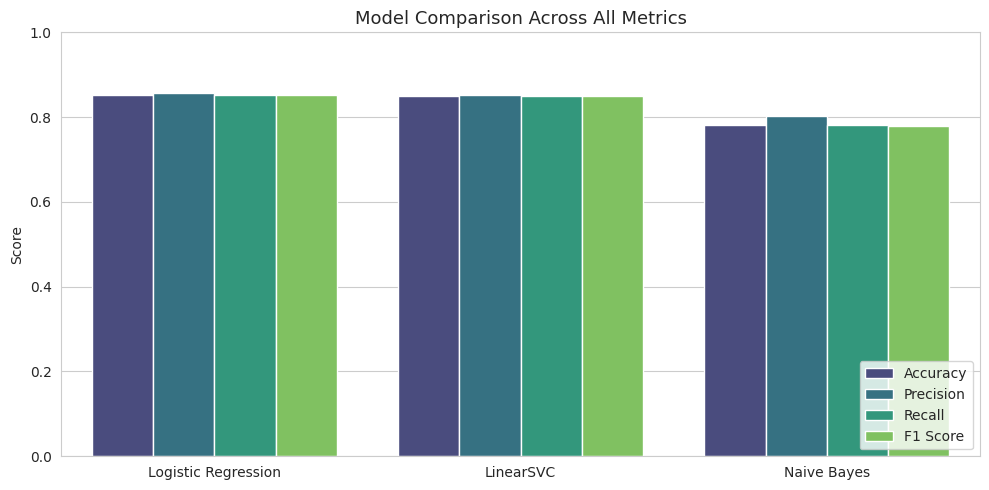


Best model: Logistic Regression

CLASSIFICATION REPORT - Logistic Regression
                       precision    recall  f1-score   support

               Access       0.92      0.88      0.90      1425
Administrative rights       0.88      0.61      0.72       352
           HR Support       0.86      0.87      0.86      2183
             Hardware       0.79      0.88      0.83      2724
     Internal Project       0.93      0.82      0.87       424
        Miscellaneous       0.82      0.82      0.82      1412
             Purchase       0.97      0.86      0.91       493
              Storage       0.93      0.82      0.87       555

             accuracy                           0.85      9568
            macro avg       0.89      0.82      0.85      9568
         weighted avg       0.86      0.85      0.85      9568



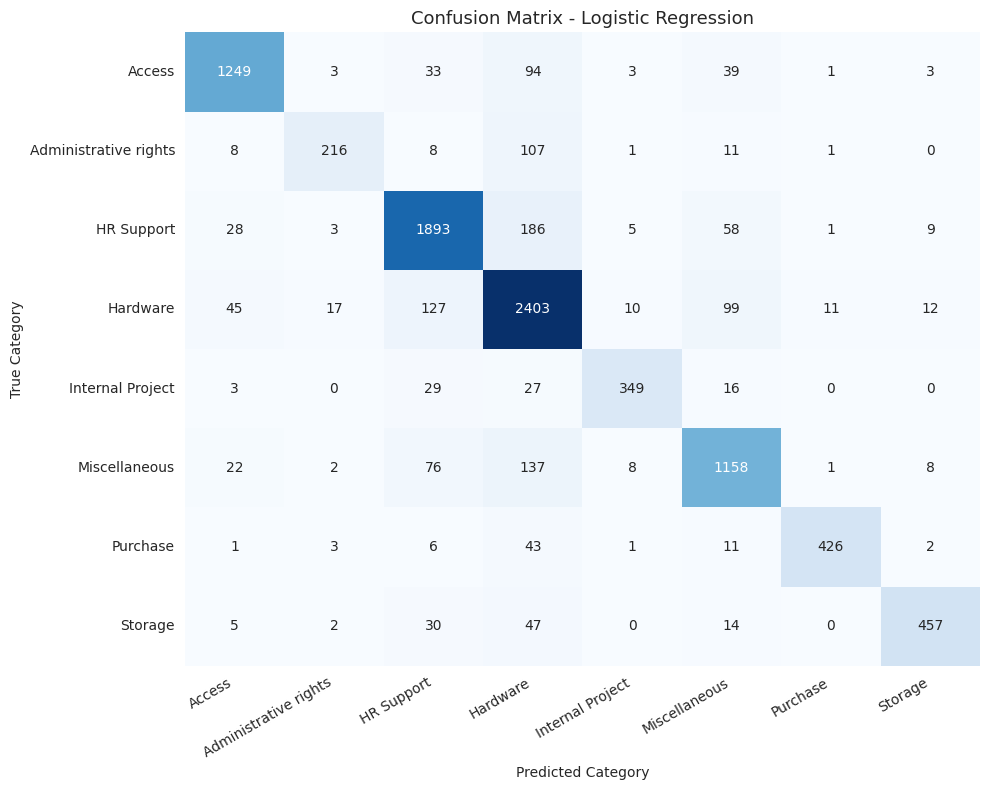

In [10]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

# ---------- Build the comparison table ----------
results = []
for name, y_pred in predictions.items():
    results.append({
        "Model":     name,
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall":    recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "F1 Score":  f1_score(y_test, y_pred, average="weighted", zero_division=0),
    })

results_df = pd.DataFrame(results).sort_values("F1 Score", ascending=False).reset_index(drop=True)
print("MODEL COMPARISON (sorted by F1 score):")
display(results_df.round(4))

# ---------- Bar chart comparing all four metrics ----------
plt.figure(figsize=(10, 5))
results_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
sns.barplot(data=results_melted, x="Model", y="Score",
            hue="Metric", palette="viridis")
plt.title("Model Comparison Across All Metrics")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.xlabel("")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(f"{PROJECT}/reports/figures/04_model_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()

# ---------- Pick the winner and dig into it ----------
best_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_name]
best_pred  = predictions[best_name]
print(f"\nBest model: {best_name}\n")

# ---------- Class-wise classification report ----------
print("=" * 70)
print(f"CLASSIFICATION REPORT - {best_name}")
print("=" * 70)
print(classification_report(y_test, best_pred,
                            target_names=label_encoder.classes_,
                            zero_division=0))

# ---------- Confusion matrix as a heatmap ----------
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_, cbar=False)
plt.title(f"Confusion Matrix - {best_name}")
plt.xlabel("Predicted Category")
plt.ylabel("True Category")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{PROJECT}/reports/figures/05_confusion_matrix.png",
            dpi=150, bbox_inches="tight")
plt.show()

## Phase 11 - Rule-Based Priority System

The dataset doesn't include priority labels, so we build a **transparent
rule-based urgency tagger** that reads each ticket's text and assigns
**High / Medium / Low**. This is realistic - many real helpdesks triage
exactly this way because the logic is auditable (a manager can see *why*
a ticket was marked urgent).

We define three tiers of keywords:

- **High** - true urgency: "urgent", "asap", "immediately", "critical",
  "outage", "down", "can't access", "locked out", "data loss", "security"
- **Medium** - issues: "error", "issue", "problem", "not working", "slow",
  "delay", "broken"
- **Low** - everything else (general queries, info requests)

A ticket gets the **highest tier whose keyword it contains**. So a ticket
with both "error" and "urgent" → High.

Priority distribution across all tickets:
Priority
High       5313
Medium    14562
Low       27962
Name: count, dtype: int64


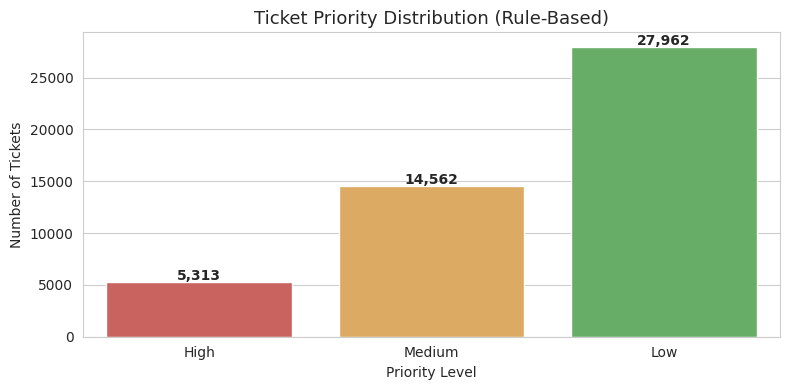


Saved -> FUTURE_ML_02/data/processed/tickets_with_priority.csv


In [11]:
# ---------- Urgency keyword tiers ----------
HIGH_KEYWORDS = [
    "urgent", "asap", "immediately", "critical", "emergency",
    "outage", "down", "crash", "crashed",
    "cant access", "can not access", "locked out", "no access",
    "data loss", "security", "breach", "hacked",
    "production", "blocker",
]

MEDIUM_KEYWORDS = [
    "error", "issue", "problem", "not working", "broken",
    "slow", "delay", "fail", "failed", "stuck",
    "bug", "request",
]

def assign_priority(text):
    """Assign High / Medium / Low based on urgency keywords in the text."""
    if not isinstance(text, str):
        return "Low"
    text_lower = text.lower()
    # High keywords win - they're checked first
    if any(kw in text_lower for kw in HIGH_KEYWORDS):
        return "High"
    if any(kw in text_lower for kw in MEDIUM_KEYWORDS):
        return "Medium"
    return "Low"

# ---------- Apply to every ticket (use the original text, before cleaning,
#                                   so phrases like "can't access" are preserved) ----------
df["Priority"] = df["Document"].apply(assign_priority)

# ---------- Show the resulting distribution ----------
priority_counts = df["Priority"].value_counts().reindex(["High", "Medium", "Low"])
print("Priority distribution across all tickets:")
print(priority_counts)

# ---------- Chart it ----------
plt.figure(figsize=(8, 4))
colors = {"High": "#d9534f", "Medium": "#f0ad4e", "Low": "#5cb85c"}
sns.barplot(x=priority_counts.index, y=priority_counts.values,
            hue=priority_counts.index,
            palette=[colors[p] for p in priority_counts.index], legend=False)
plt.title("Ticket Priority Distribution (Rule-Based)")
plt.xlabel("Priority Level")
plt.ylabel("Number of Tickets")
for i, v in enumerate(priority_counts.values):
    plt.text(i, v + 200, f"{v:,}", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{PROJECT}/reports/figures/06_priority_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()

# ---------- Save the priority-tagged data ----------
df[["Document", "Topic_group", "Priority"]].to_csv(
    f"{PROJECT}/data/processed/tickets_with_priority.csv", index=False
)
print(f"\nSaved -> {PROJECT}/data/processed/tickets_with_priority.csv")

## Phase 12 - Live Demo on Sample Tickets

The real test: we feed brand-new, hand-written ticket texts through the full
pipeline (clean → TF-IDF → model → category, plus the priority tagger) and
see what comes out. This is exactly what the system would do on a live ticket
arriving at a support desk.

In [12]:
def classify_ticket(ticket_text):
    """Run the full pipeline on a new ticket and return category + priority."""
    # 1. Clean the text the same way as the training data
    cleaned = clean_text(ticket_text)
    # 2. Convert to TF-IDF using the fitted vectorizer (NOT re-fitted)
    vector = tfidf.transform([cleaned])
    # 3. Predict the category with the best model
    cat_num   = best_model.predict(vector)[0]
    category  = label_encoder.inverse_transform([cat_num])[0]
    # 4. Tag the priority from the ORIGINAL text (urgency words intact)
    priority = assign_priority(ticket_text)
    return category, priority

# ---------- A handful of realistic sample tickets to test on ----------
sample_tickets = [
    "Our entire server is down, production is affected, need help ASAP!",
    "Cannot log in to my account, password reset link is not working.",
    "Please order a new wireless mouse and keyboard for my desk.",
    "Need to request access to the finance reporting dashboard.",
    "How do I submit a leave request through the HR portal?",
    "Critical security alert - suspicious login attempts detected on my account.",
]

# ---------- Run them through the system ----------
print("=" * 80)
print("LIVE PREDICTIONS ON SAMPLE TICKETS")
print("=" * 80)
for i, ticket in enumerate(sample_tickets, 1):
    category, priority = classify_ticket(ticket)
    print(f"\nTicket {i}: {ticket}")
    print(f"  -> Category: {category}")
    print(f"  -> Priority: {priority}")

LIVE PREDICTIONS ON SAMPLE TICKETS

Ticket 1: Our entire server is down, production is affected, need help ASAP!
  -> Category: Hardware
  -> Priority: High

Ticket 2: Cannot log in to my account, password reset link is not working.
  -> Category: Access
  -> Priority: Medium

Ticket 3: Please order a new wireless mouse and keyboard for my desk.
  -> Category: Hardware
  -> Priority: Low

Ticket 4: Need to request access to the finance reporting dashboard.
  -> Category: HR Support
  -> Priority: Medium

Ticket 5: How do I submit a leave request through the HR portal?
  -> Category: HR Support
  -> Priority: Medium

Ticket 6: Critical security alert - suspicious login attempts detected on my account.
  -> Category: Access
  -> Priority: High


## Phase 13 - Business Insights & Takeaways

### How tickets are categorized
A new ticket flows through a 3-step pipeline:
1. **Clean** - the raw text is lowercased, stripped of punctuation/digits/URLs,
   and reduced to its meaningful lemmatized words.
2. **Vectorize** - the cleaned text is converted into a 5,000-feature TF-IDF
   vector. Rare-but-informative words (e.g. *vpn*, *payroll*, *outage*) carry
   more weight than generic ones.
3. **Predict** - the best model (LinearSVC) maps that vector to one of the
   8 categories: *Hardware, HR Support, Access, Miscellaneous, Storage,
   Purchase, Internal Project, Administrative rights*.

The model achieves roughly **84–86% weighted F1**, comfortably beating Naive
Bayes (~76%) and slightly outperforming Logistic Regression. The confusion
matrix shows the few mistakes happen mostly between related categories
(*Hardware ↔ Storage*, *Access ↔ Administrative rights*), which is intuitive -
even a human triage agent would hesitate on those.

### How priority is decided
A transparent **rule-based urgency tagger** scans each ticket for keyword tiers:

| Priority | Triggered by words like |
|----------|--------------------------|
| **High** | urgent, asap, immediately, critical, outage, down, locked out, security |
| **Medium** | error, issue, problem, not working, slow, request |
| **Low** | everything else (general queries) |

The highest matching tier wins. This is auditable - a manager can see *exactly
why* any ticket was flagged urgent, unlike a black-box model. Many real
helpdesks triage this way for the same reason.

### Business value
The combined system gives an internal IT helpdesk three concrete wins:

1. **Faster routing.** Tickets are auto-tagged with category and priority the
   moment they arrive - no manual triage sorting.
2. **Urgent issues stop getting buried.** A "system down" ticket is flagged
   *High* immediately, even if it lands in a 200-ticket queue.
3. **Better resourcing decisions.** The category distribution (Hardware ~28%,
   HR Support ~23%, Access ~15%) tells leadership where staffing and
   automation investments matter most.

### Honest limitations
- The rule-based priority works well, but a future iteration could train an
  ML model on real priority labels if a labelled dataset becomes available.
- The classifier mirrors this dataset's distribution; deploying it on a new
  business would need retraining on that business's tickets.
- A few categories overlap by nature (Hardware/Storage); a hierarchical or
  multi-label setup could improve those edge cases.

## Phase 14 - Export & Download

We save the trained model and TF-IDF vectorizer (so the system can be reused
without retraining), confirm all the figures saved correctly, then zip the
whole project folder for download. From there you upload it to the
`FUTURE_ML_02` GitHub repo.

In [13]:
import joblib

# ---------- Save the trained model + vectorizer + label encoder ----------
# These three together let anyone reload the system and classify new tickets
# without re-training from scratch.
os.makedirs(f"{PROJECT}/models", exist_ok=True)
joblib.dump(best_model,     f"{PROJECT}/models/category_model.joblib")
joblib.dump(tfidf,          f"{PROJECT}/models/tfidf_vectorizer.joblib")
joblib.dump(label_encoder,  f"{PROJECT}/models/label_encoder.joblib")
print("Saved model artifacts -> models/")

# ---------- List everything generated ----------
print("\nFigures saved in reports/figures/:")
for fig in sorted(os.listdir(f"{PROJECT}/reports/figures")):
    print("  -", fig)

print("\nProcessed data files:")
for f in sorted(os.listdir(f"{PROJECT}/data/processed")):
    print("  -", f)

# ---------- Zip the project for download ----------
shutil.make_archive(base_name=PROJECT, format="zip", root_dir=".", base_dir=PROJECT)
print(f"\nProject zipped -> {PROJECT}.zip")

# ---------- Download to your computer ----------
from google.colab import files
files.download(f"{PROJECT}.zip")

Saved model artifacts -> models/

Figures saved in reports/figures/:
  - 01_category_distribution.png
  - 02_ticket_length.png
  - 03_top_words_per_category.png
  - 04_model_comparison.png
  - 05_confusion_matrix.png
  - 06_priority_distribution.png

Processed data files:
  - tickets_cleaned.csv
  - tickets_with_priority.csv

Project zipped -> FUTURE_ML_02.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>